In [ ]:
!pip install -q tensorflow-io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 90.7 MB/s eta 0:00:00


In [ ]:
!pip install librosa

In [ ]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
!wget https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz


--2026-04-13 17:37:24--  https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.179.207, 64.233.180.207, 172.253.62.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.179.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2428923189 (2.3G) [application/gzip]
Saving to: ‘speech_commands_v0.02.tar.gz’

speech_commands_v0. 100%[===================>]   2.26G  22.5MB/s    in 22s     

2026-04-13 17:37:47 (104 MB/s) - ‘speech_commands_v0.02.tar.gz’ saved [2428923189/2428923189]



In [ ]:
!tar -xzf speech_commands_v0.02.tar.gz


In [ ]:
import os

# The archive extracts files into the current directory, not a subfolder
base_path = "."

# Filter to show only directories to verify classes
print([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))][:20])

classes = ["left", "right", "forward", "backward"]

for c in classes:
    path = os.path.join(base_path, c)
    if os.path.exists(path):
        print(c, "→", len(os.listdir(path)))
    else:
        print(c, "→ folder not found")

['.config', 'right', 'three', 'down', 'go', 'backward', 'off', 'up', 'yes', 'dog', 'eight', 'learn', 'visual', 'bed', 'seven', 'wow', 'house', 'tree', 'zero', 'four']
left → 3801
right → 3778
forward → 1557
backward → 1664


In [ ]:
import librosa
import numpy as np

sample_file = os.path.join(base_path, "left", os.listdir(os.path.join(base_path, "left"))[0])

audio, sr = librosa.load(sample_file, sr=16000)

print("Shape:", audio.shape)
print("Sample rate:", sr)

Shape: (16000,)
Sample rate: 16000


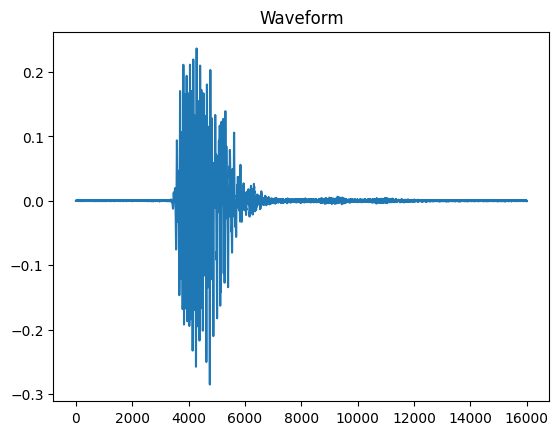

In [ ]:
import matplotlib.pyplot as plt

plt.plot(audio)
plt.title("Waveform")
plt.show()

Shape: (13, 32)


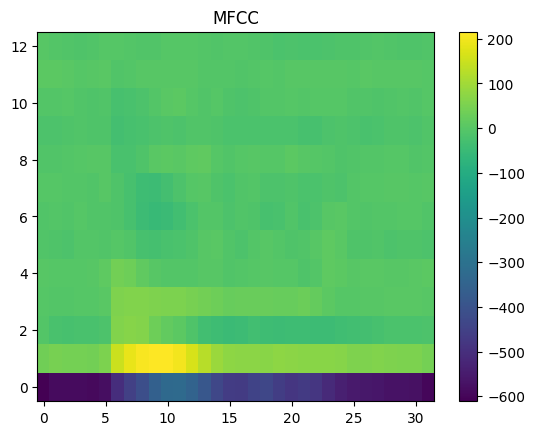

In [ ]:
import librosa
import matplotlib.pyplot as plt

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr ,
    n_mfcc = 13 # standard number of coef
)
print("Shape:", MFCC.shape)

plt.imshow(mfcc, aspect='auto', origin='lower')
plt.title("MFCC")
plt.colorbar()
plt.show()

In [ ]:
MAX_LEN = 32  # adjust based on your MFCC width

def pad_mfcc(mfcc, max_len=MAX_LEN):
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

mfcc_fixed = pad_mfcc(mfcc)

def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc = pad_mfcc(mfcc)
    return mfcc

print(extract_features(sample_file).shape)

(13, 32)


In [ ]:
import matplotlib.pyplot as plt

def plot_mfcc(mfcc):
    plt.figure(figsize=(6, 4))
    plt.imshow(mfcc, aspect='auto', origin='lower')
    plt.title("MFCC")
    plt.xlabel("Time")
    plt.ylabel("MFCC Coefficients")
    plt.colorbar()
    plt.show()


In [ ]:
import numpy as np
import os

# Create a directory to save the MFCCs
mfcc_output_dir = os.path.join(base_path, "mfcc_data")
os.makedirs(mfcc_output_dir, exist_ok=True)

# Iterate over audio files
for c in classes:
    class_path = os.path.join(base_path, c)

    # Create a subdirectory for each class inside mfcc_output_dir
    class_mfcc_output_dir = os.path.join(mfcc_output_dir, c)
    os.makedirs(class_mfcc_output_dir, exist_ok=True)

    files = os.listdir(class_path)
    for file_name in files:
        if file_name.endswith(".wav"):  # Ensure we only process .wav files
            file_path = os.path.join(class_path, file_name)
            mfcc_features = extract_features(file_path)
            normalized_mfcc = (mfcc_features - np.mean(mfcc_features)) / np.std(mfcc_features)   # important
            # Save the MFCC features to the class-specific subdirectory
            output_filename = os.path.join(class_mfcc_output_dir, f"{os.path.splitext(file_name)[0]}.npy")
            np.save(output_filename, normalized_mfcc)
print(f"MFCC features for all classes saved to: {mfcc_output_dir} with class-specific subfolders.")

MFCC features for all classes saved to: ./mfcc_data with class-specific subfolders.


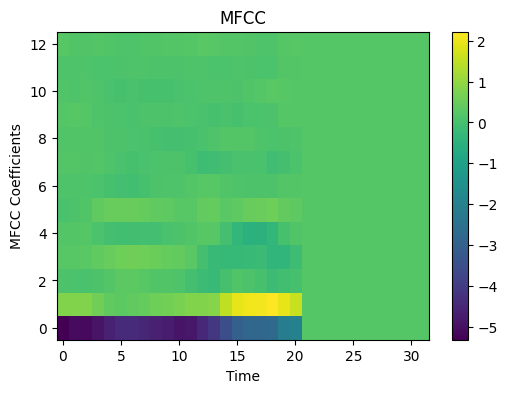

In [ ]:
sample = np.load("/content/mfcc_data/forward/012187a4_nohash_0.npy")
plot_mfcc(sample)

In [ ]:
import os
import numpy as np
import tensorflow as tf

data_path = "mfcc_data"

X = []
y = []

for label, cls in enumerate(classes):
    class_path = os.path.join(data_path, cls)

    for file in os.listdir(class_path):
        if file.endswith(".npy"):
            file_path = os.path.join(class_path, file)

            mfcc = np.load(file_path)

            X.append(mfcc)
            y.append(label)


X = np.array(X)
y = np.array(y)
X = X[..., tf.newaxis]
y  = y[..., tf.newaxis]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10800, 13, 32, 1)
y shape: (10800, 1)


In [ ]:
from sklearn.utils import shuffle
X , y = shuffle(X, y , random_state=42)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(8640, 13, 32, 1) (2160, 13, 32, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers , models

model = models.Sequential()
# Corrected input_shape to (13, 32, 1) and added padding='same'
model.add(layers.Conv2D(8, (3, 3), activation='relu', input_shape=(13, 32, 1), padding='same'))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(4, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 13, 32, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 6, 16, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 6, 16, 16)      │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 3, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 3, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 1, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,404 (40.64 KB)

 Trainable params: 10,404 (40.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    batch_size=16,
    epochs=20,
)

Epoch 1/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6167 - loss: 0.8416 - val_accuracy: 0.8509 - val_loss: 0.4470
Epoch 2/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8858 - loss: 0.3274 - val_accuracy: 0.8824 - val_loss: 0.3198
Epoch 3/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9204 - loss: 0.2279 - val_accuracy: 0.9194 - val_loss: 0.2324
Epoch 4/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9338 - loss: 0.1920 - val_accuracy: 0.9310 - val_loss: 0.1922
Epoch 5/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9407 - loss: 0.1596 - val_accuracy: 0.9380 - val_loss: 0.1737
Epoch 6/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9505 - loss: 0.1398 - val_accuracy: 0.9306 - val_loss: 0.1880
Epoch 7/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9546 - loss: 0.1256 - val_accuracy: 0.9426 - val_loss: 0.1643
Epoch 8/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9590 - loss: 0.1124 - val_ac

In [ ]:
from sklearn.metrics import classification_report, f1_score
y_pred_probs = model.predict(X_test)

y_pred = y_pred_probs.argmax(axis=1)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1-score (macro):", f1)
classes = ["left", "right", "forward", "backward"]

print(classification_report(y_test, y_pred, target_names=classes))

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
F1-score (macro): 0.95840934303604
              precision    recall  f1-score   support

        left       0.96      0.97      0.97       745
       right       0.98      0.95      0.96       729
     forward       0.93      0.96      0.94       353
    backward       0.94      0.95      0.95       333

    accuracy                           0.96      2160
   macro avg       0.95      0.96      0.95      2160
weighted avg       0.96      0.96      0.96      2160



In [ ]:
model.save('speech_command_model.h5')
print("Model saved as 'speech_command_model.h5'")

Model saved as 'speech_command_model.h5'


In [ ]:
import librosa
import numpy as np

MAX_LEN = 32  # same as training

def preprocess_audio(file_path):
    # Load audio
    audio, sr = librosa.load(file_path, sr=16000)

    # Extract MFCC
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

    # Pad / truncate
    if mfcc.shape[1] < MAX_LEN:
        pad_width = MAX_LEN - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :MAX_LEN]

    # Normalize (IMPORTANT — same as training)
    mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) )

    # Add channel + batch dimension
    mfcc = mfcc[..., np.newaxis]   # (13, 32, 1)
    mfcc = np.expand_dims(mfcc, axis=0)  # (1, 13, 32, 1)

    return mfcc

def predict_audio(file_path, model):
    mfcc = preprocess_audio(file_path)

    prediction = model.predict(mfcc)

    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    return classes[predicted_class], confidence

In [ ]:
file_path = "/content/backward.ogg"  # upload your file in Colab

label, conf = predict_audio(file_path, model)

print("Prediction:", label)
print("Confidence:", conf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction: backward
Confidence: 0.9935296


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

size_kb = os.path.getsize("model.tflite") / 1024
print("TFLite size:", size_kb, "KB")

Saved artifact at '/tmp/tmpzbplz7ve'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 32, 1), dtype=tf.float32, name='keras_tensor_296')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138801729782608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138801729787216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138801729788752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138801729782224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138801729785104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138801729785680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138801729787600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138801729787984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138801729783760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138801729789712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138801729784

In [ ]:
interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_keras_tensor_296:0', 'index': 0, 'shape': array([ 1, 13, 32,  1], dtype=int32), 'shape_signature': array([-1, 13, 32,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 32, 'shape': array([1, 4], dtype=int32), 'shape_signature': array([-1,  4], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
def tflite_predict(file_path):
    mfcc = preprocess_audio(file_path)  # same function you built

    # Ensure correct dtype
    mfcc = mfcc.astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'], mfcc)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])

    predicted_class = np.argmax(output)
    confidence = np.max(output)

    return classes[predicted_class], confidence

In [ ]:
label, conf = tflite_predict("/content/left.ogg")

print("Prediction:", label)
print("Confidence:", conf)

Prediction: left
Confidence: 0.984271
